# Export delivered loads from last available month

Reads the dimensional model from Postgres and exports a CSV with the `loadsmart_id`s delivered in the last available month of the dataset.

**Assumptions:**
- *Delivered* = `fact_loads.delivery_date` is not null and `load_was_cancelled` is not true.
- *Last available month* = December 2024 (12/2024). Based on the month distribution analysis above, this is the last month with complete data (497 loads). Months 2025-01 (65 loads) and 2025-03 (1 load) are excluded as considered that they contain incomplete data.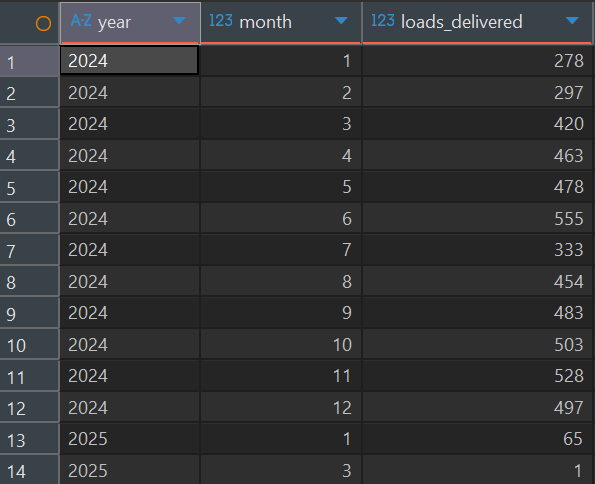

## 1. Imports

In [1]:
import os
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy.engine import Engine

## 2. DB connection

Reads `DATABASE_URL` from `.env` (repo root) and loads each mart table into a `DataFrame`.

In [12]:
DB_SCHEMA = os.getenv("DB_SCHEMA", "analytics")
MART_TABLES = ["fact_loads", "dim_lane", "dim_location", "dim_shipper", "dim_carrier"]


def get_db_engine():
    load_dotenv()
    database_url = os.getenv("DATABASE_URL")
    return create_engine(database_url)


def read_mart_tables(engine: Engine, schema: str = DB_SCHEMA):
    return {table: pd.read_sql_table(table, engine, schema=schema) for table in MART_TABLES}

In [5]:
engine = get_db_engine()
tables = read_mart_tables(engine)
{name: len(df) for name, df in tables.items()}

{'fact_loads': 5355,
 'dim_lane': 1570,
 'dim_location': 988,
 'dim_shipper': 94,
 'dim_carrier': 2202}

## 3. Pandas logic

Join the star schema in pandas (`fact_loads` + dims), keep only delivered loads, then narrow down to the last available month.

In [11]:
def join_dimensional_model(tables: dict[str, pd.DataFrame]):
    fact = tables["fact_loads"]
    lane = tables["dim_lane"][["lane_id", "source_location_id", "target_location_id"]]
    location = tables["dim_location"][["location_id", "city", "state"]]
    shipper = tables["dim_shipper"][["shipper_id", "shipper_name"]]
    carrier = tables["dim_carrier"][["carrier_id", "carrier_name"]]

    pickup_location = location.rename(
        columns={"location_id": "source_location_id", "city": "pickup_city", "state": "pickup_state"}
    )
    delivery_location = location.rename(
        columns={"location_id": "target_location_id", "city": "delivery_city", "state": "delivery_state"}
    )

    return (
        fact
        .merge(lane, on="lane_id", how="left")
        .merge(pickup_location, on="source_location_id", how="left")
        .merge(delivery_location, on="target_location_id", how="left")
        .merge(shipper, on="shipper_id", how="left")
        .merge(carrier, on="carrier_id", how="left")
    )


def filter_delivered(loads: pd.DataFrame):
    is_delivered = loads["delivery_date"].notna() & ~loads["load_was_cancelled"].fillna(False)
    return loads[is_delivered].copy()


LAST_AVAILABLE_MONTH = "2024-12"


def filter_last_available_month(
    delivered: pd.DataFrame, date_col: str = "delivery_date", target_month: str = LAST_AVAILABLE_MONTH
):
    delivered[date_col] = pd.to_datetime(delivered[date_col])
    target_period = pd.Period(target_month, freq="M")
    return delivered[delivered[date_col].dt.to_period("M") == target_period]

In [7]:
EXPORT_COLUMNS = [
    "loadsmart_id",
    "shipper_name",
    "delivery_date",
    "pickup_city",
    "pickup_state",
    "delivery_city",
    "delivery_state",
    "book_price",
    "carrier_name",
]

loads = join_dimensional_model(tables)
delivered = filter_delivered(loads)
last_month_loads = filter_last_available_month(delivered)

export_df = last_month_loads[EXPORT_COLUMNS].sort_values("loadsmart_id").reset_index(drop=True)
export_df

,loadsmart_id,shipper_name,delivery_date,pickup_city,pickup_state,delivery_city,delivery_state,book_price,carrier_name
0,206422137,Shipper 585,2024-12-12 11:00:00,Plant City,FL,Commerce,GA,600.00,Carrier 34822
1,206423225,Shipper 1644,2024-12-02 10:15:00,North Charleston,SC,Laredo,TX,2963.12,Carrier 1687657
2,206423241,Shipper 1249,2024-12-18 13:00:00,Granite City,IL,Knoxville,TN,1839.73,Carrier 51278
3,206423585,Shipper 585,2024-12-14 10:35:00,Crete,IL,Plant City,FL,4600.00,Carrier 1044520
4,206423593,Shipper 1249,2024-12-22 19:00:00,Newark,NJ,Boise,ID,4478.80,Carrier 1241642
...,...,...,...,...,...,...,...,...,...
437,206754289,Shipper 1249,2024-12-08 11:00:00,Fort Collins,CO,Union Gap,WA,2737.44,Carrier 797827
438,206754297,Shipper 758,2024-12-13 13:55:00,Kent,WA,Spokane,WA,745.04,Carrier 1356147
439,206754313,Shipper 1644,2024-12-15 18:40:00,Mount Airy,NC,Swedesboro,NJ,1704.69,Carrier 511984
440,206775177,Shipper 1644,2024-12-01 11:00:00,Paragould,AR,Reno,NV,4324.90,Carrier 1237001


## 4. Export file

In [9]:
def export_to_csv(df: pd.DataFrame, output_path: Path) -> Path:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(output_path, index=False)
    return output_path


output_path = export_to_csv(export_df, Path("last_month_loads.csv"))
print(f"Exported {len(export_df)} rows to {output_path.resolve()}")

Exported 442 rows to /home/lorenzocoracini/Documents/analytics-engineer-challenge/export_notebook/last_month_loads.csv
